In [50]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [38]:
df = pd.read_csv(r"C:\Users\malum\Desktop\faculdade\learning_machine\dados\creditcard.csv")


In [30]:


import plotly.express as px

contagem_classes = df['Class'].value_counts().reset_index()
contagem_classes.columns = ['Classe', 'Total']
contagem_classes['Classe'] = contagem_classes['Classe'].map({0: 'Normal (Legítima)', 1: 'Fraude'})

fig = px.bar(
    contagem_classes, 
    x='Classe', 
    y='Total',
    text='Total', # Mostra o número exato em cima da barra
    title='O Desafio do Desbalanceamento Absoluto de Dados',
    labels={'Total': 'Número de Transações (Escala Log)', 'Classe': 'Tipo de Transação'},
    color='Classe',
    color_discrete_map={'Normal (Legítima)': '#2ecc71', '#e74c3c': 'Fraude'} 
)

fig.update_traces(textposition='outside')

fig.update_layout(
    height=500, 
    template='plotly_dark',
    yaxis_type="log" 
)

fig.show()

In [31]:
print("Credit Card Fraud Detection data -  rows:",df.shape[0]," columns:", df.shape[1])


Credit Card Fraud Detection data -  rows: 284807  columns: 31


In [32]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [33]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [34]:
total = df.isnull().sum().sort_values(ascending = False)
percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
pd.concat([total, percent], axis=1, keys=['Total', 'Percent']).transpose()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Total,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
temp = df["Class"].value_counts()
dataf = pd.DataFrame({'Class': temp.index,'values': temp.values})

trace = go.Bar(
    x = dataf['Class'],y = dataf['values'],
    name="Classe de Fraude - Desbalanceamento (Normal = 0, Fraude = 1)",
    marker=dict(color="Red"),
    text=dataf['values']
)
data = [trace]
layout = dict(title = 'Classe de Fraude em Cartão de Crédito - Desbalanceamento (Normal = 0, Fraude = 1)',
          xaxis = dict(title = 'Classe', showticklabels=True), 
          yaxis = dict(title = 'Número de Transações'),
          hovermode = 'closest',width=600
         )
fig_final = go.Figure(data=data, layout=layout)
fig_final.show()

In [61]:
df['Hora'] = df['Time'].apply(lambda x: np.floor(x / 3600))

df_estatisticas = df.groupby(['Hora', 'Class'])['Amount'].aggregate(
    ['min', 'max', 'count', 'sum', 'mean', 'median', 'var']
).reset_index()
df_estatisticas.columns = ['Hora','Classe', 'Minimo', 'Maximo', 'Total_Transacoes', 'Soma_Total', 'Media', 'Mediana', 'Variancia']
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Hora,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,0.0


In [62]:
class_0 = df.loc[df['Class'] == 0]["Time"]
class_1 = df.loc[df['Class'] == 1]["Time"]

dados_grafico = [class_0, class_1]
group_labels = ['Legítima', 'Fraude']

fig = ff.create_distplot(dados_grafico, group_labels, show_hist=False, show_rug=False)
fig['layout'].update(title='Gráfico de Densidade: Tempo das Transações de Cartão de Crédito', xaxis=dict(title='Tempo [s]'))
fig.show(filename='Densidade de Trnasações')

In [86]:
df['Hour'] = df['Time'].apply(lambda x: np.floor(x / 3600))

tmp = df.groupby(['Hour', 'Class'])['Amount'].aggregate(['min', 'max', 'count', 'sum', 'mean', 'median', 'var']).reset_index()
dataf = pd.DataFrame(tmp)
dataf.columns = ['Hora', 'Classe', 'Min', 'Max', 'Transações', 'Soma', 'Média', 'Mediana', 'Variância']
dataf.head()

,Hora,Classe,Min,Max,Transações,Soma,Média,Mediana,Variância
0,0.0,0,0.0,7712.43,3961,256572.87,64.774772,12.990,45615.821201
1,0.0,1,0.0,529.00,2,529.00,264.500000,264.500,139920.500000
2,1.0,0,0.0,1769.69,2215,145806.76,65.826980,22.820,20053.615770
3,1.0,1,59.0,239.93,2,298.93,149.465000,149.465,16367.832450
4,2.0,0,0.0,4002.88,1555,106989.39,68.803466,17.900,45355.430437


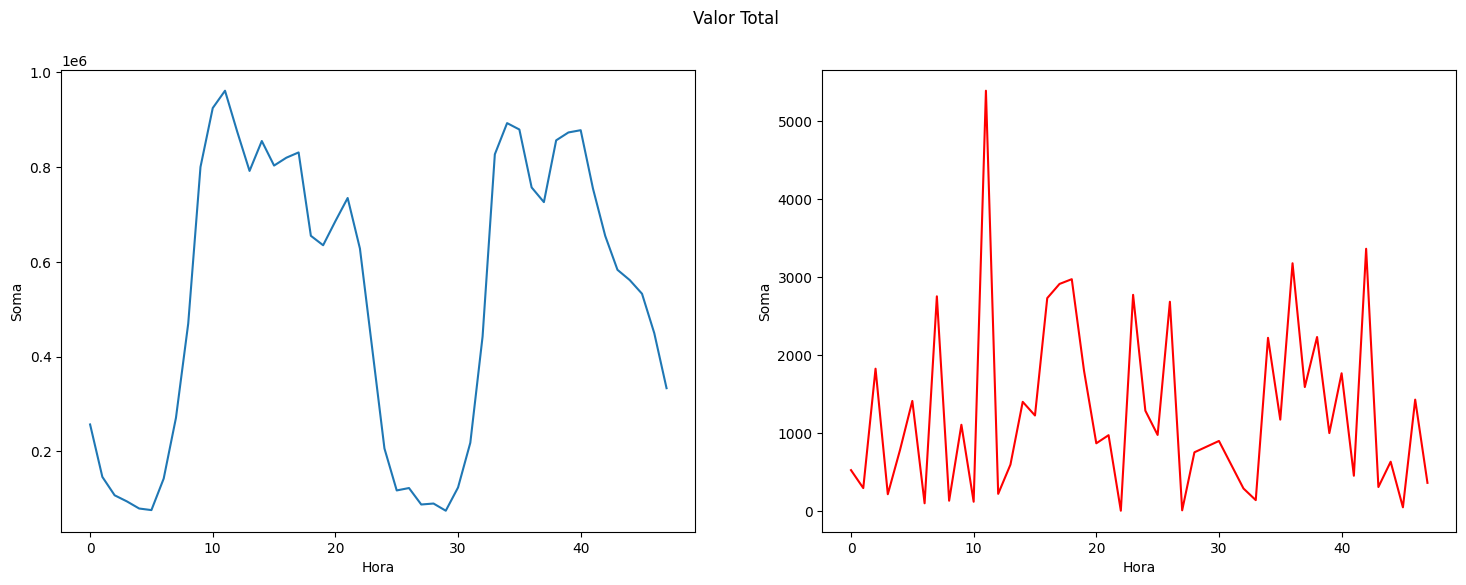

In [70]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hora", y="Soma", data=dataf.loc[dataf.Classe==0])
s = sns.lineplot(ax = ax2, x="Hora", y="Soma", data=dataf.loc[dataf.Classe==1], color="red")
plt.suptitle("Valor Total")
plt.show();

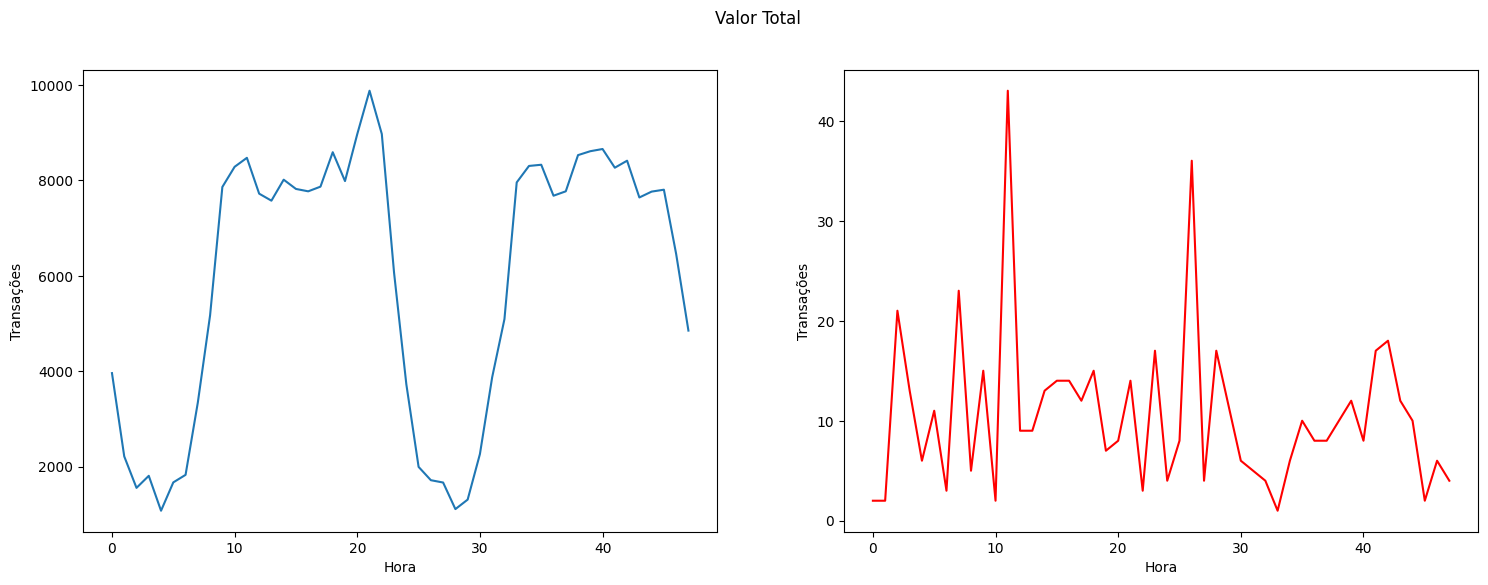

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hora", y="Transações", data=dataf.loc[dataf.Classe==0])
s = sns.lineplot(ax = ax2, x="Hora", y="Transações", data=dataf.loc[dataf.Classe==1], color="red")
plt.suptitle("Total de Transações")
plt.show();

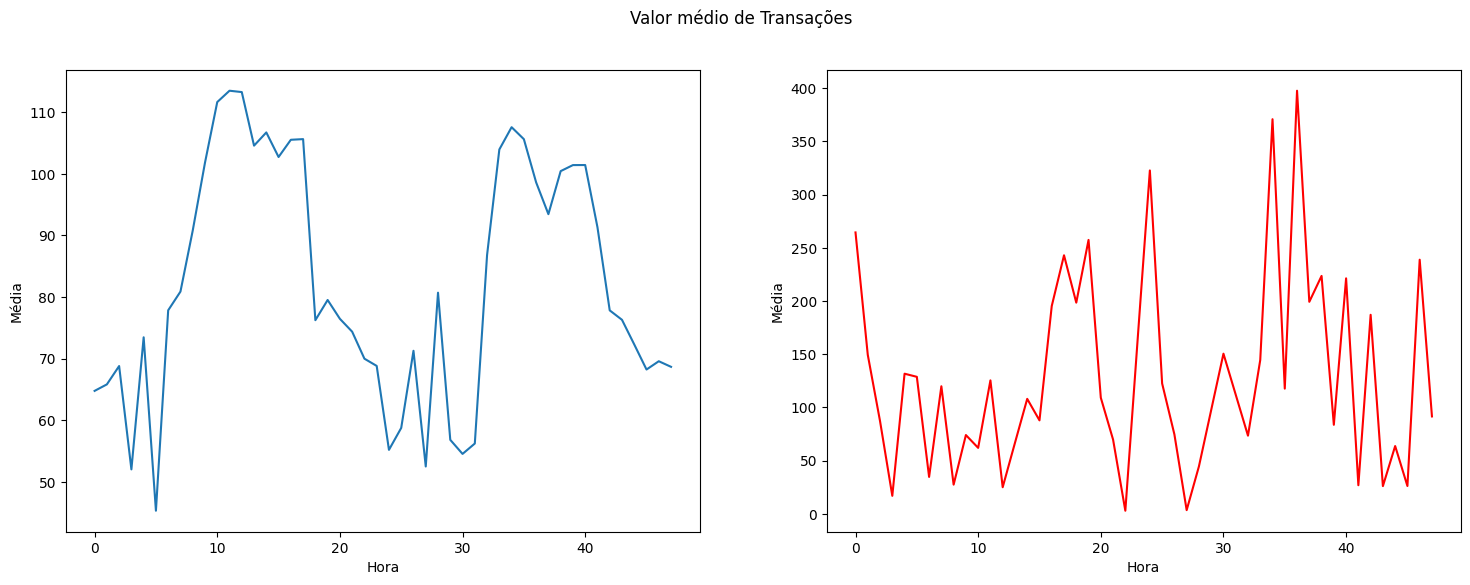

In [73]:
Transaçõefig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hora", y="Média", data=dataf.loc[dataf.Classe==0])
s = sns.lineplot(ax = ax2, x="Hora", y="Média", data=dataf.loc[dataf.Classe==1], color="red")
plt.suptitle("Valor médio de Transações")
plt.show();

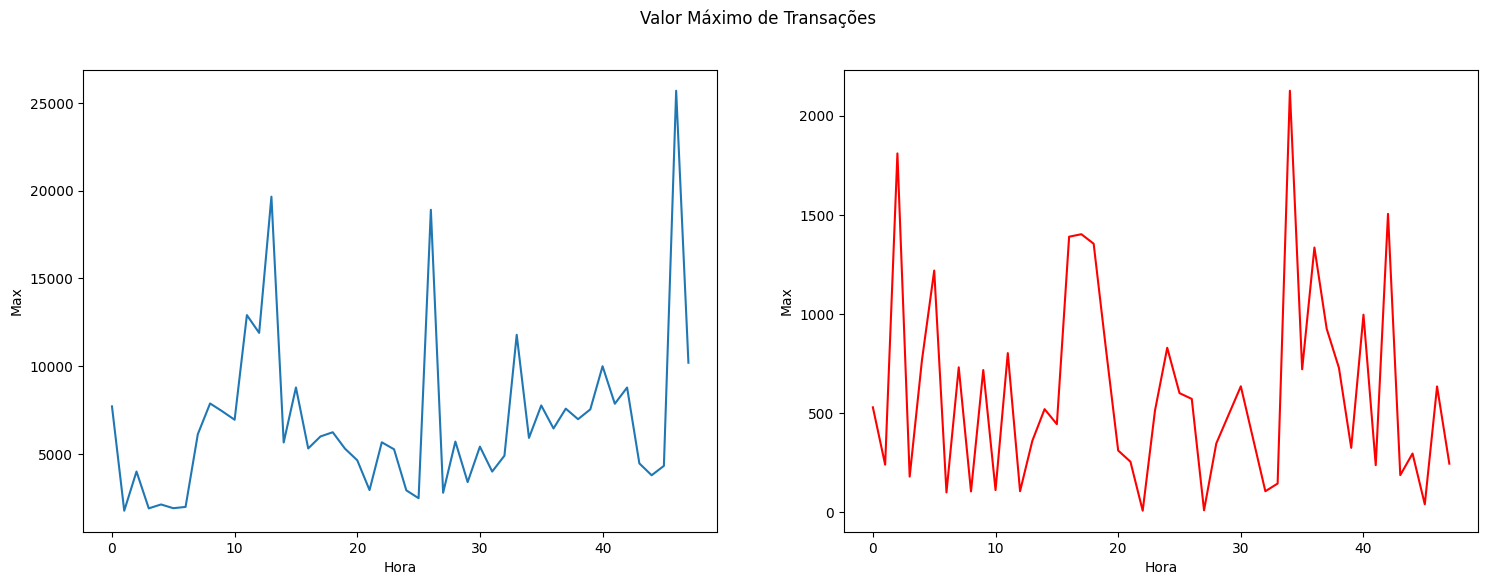

In [74]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hora", y="Max", data=dataf.loc[dataf.Classe==0])
s = sns.lineplot(ax = ax2, x="Hora", y="Max", data=dataf.loc[dataf.Classe==1], color="red")
plt.suptitle("Valor Máximo de Transações")
plt.show();

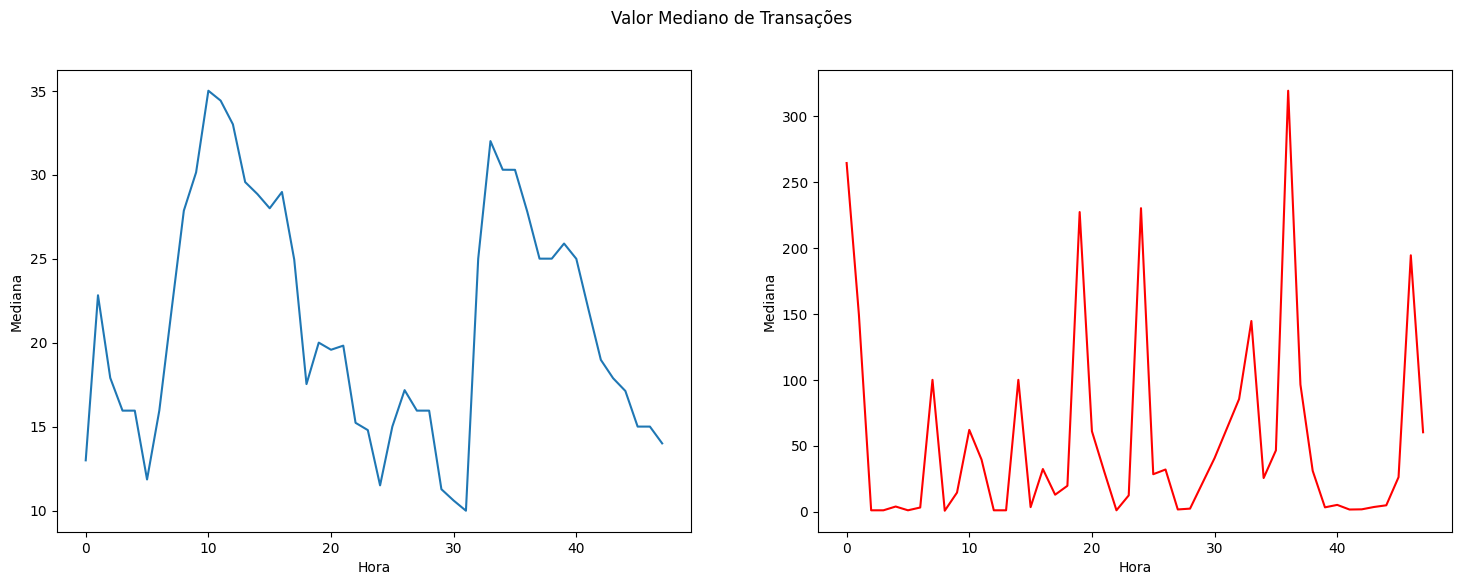

In [75]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hora", y="Mediana", data=dataf.loc[dataf.Classe==0])
s = sns.lineplot(ax = ax2, x="Hora", y="Mediana", data=dataf.loc[dataf.Classe==1], color="red")
plt.suptitle("Valor Mediano de Transações")
plt.show();

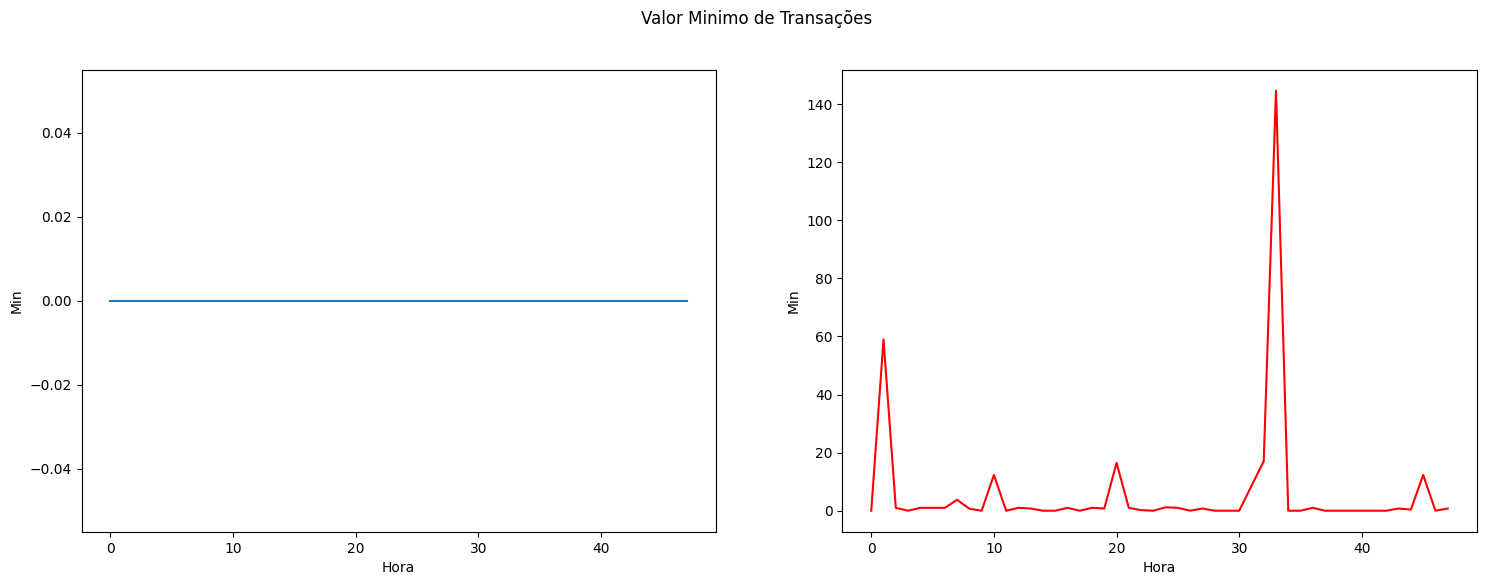

In [76]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
s = sns.lineplot(ax = ax1, x="Hora", y="Min", data=dataf.loc[dataf.Classe==0])
s = sns.lineplot(ax = ax2, x="Hora", y="Min", data=dataf.loc[dataf.Classe==1], color="red")
plt.suptitle("Valor Minimo de Transações")
plt.show();

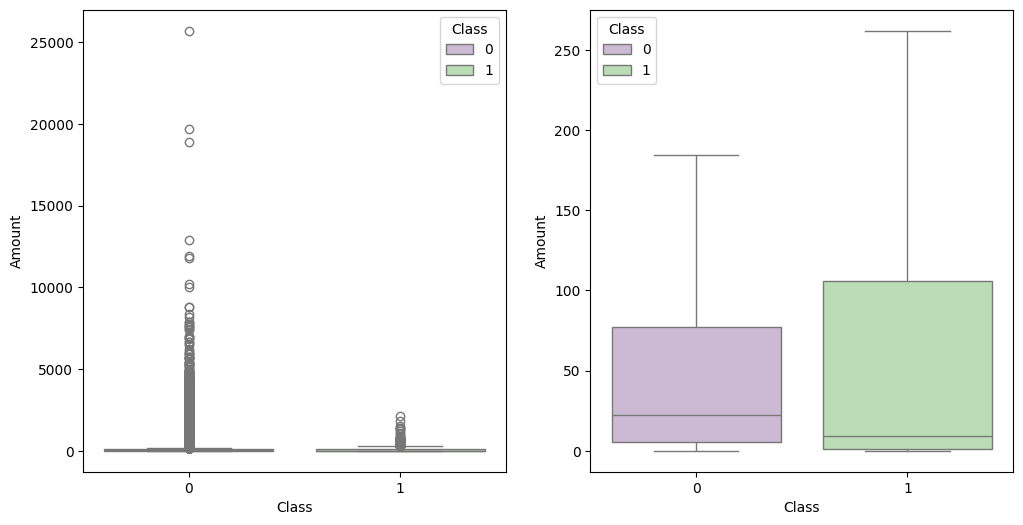

In [82]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))
s = sns.boxplot(ax = ax1, x="Class", y="Amount", hue="Class",data=df, palette="PRGn",showfliers=True)
s = sns.boxplot(ax = ax2, x="Class", y="Amount", hue="Class",data=df, palette="PRGn",showfliers=False)
plt.show();

In [83]:
tmp = df[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']
class_0.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64